In [1]:
# краткая документация по назначению ноутбука
"""
назначение: детекция fan-in/fan-out паттернов в elliptic bitcoin transaction dataset.
основные шаги: загрузка csv, построение directed-графа, degree-filter,
flowscope-inspired scoring, hub-признаки, semi-supervised gat и оценка метрик.
зависимости и источники: pandas, numpy, networkx, scikit-learn, torch,
torch_geometric, tqdm, elliptic_txs_features.csv, elliptic_txs_edgelist.csv,
elliptic_txs_classes.csv.
ключевые переменные:
- features_df: таблица признаков транзакций, где txid является идентификатором узла.
- edges_df: directed-рёбра txid1 -> txid2, задающие поток между транзакциями.
- classes_df: частичная разметка licit/illicit/unknown для оценки качества.
- graph: directed-граф networkx, на котором считаются степени и локальные подграфы.
- hub_features: node-level признаки fan-in, fan-out, bipartite и anomalousness score.
принцип функций:
- нормализация score переводит разные эвристики в общий диапазон 0..1.
- визуализация hub получает центр и радиус, возвращает локальный графовый фрагмент.
- gat получает матрицу признаков и edge_index, возвращает вероятности классов узлов.
гипотезы:
- высокий in_degree похож на консолидацию средств из многих источников.
- высокий out_degree похож на распределение средств по многим получателям.
- bipartite hub важнее одиночного порога степени, потому что совмещает входящий и исходящий поток.
"""

'\nназначение: детекция Fan-in/Fan-out паттернов в Elliptic Bitcoin Transaction Dataset.\nосновные шаги: загрузка CSV, построение directed-графа, degree-filter,\nFlowScope-inspired scoring, hub-признаки, semi-supervised GAT и оценка метрик.\nзависимости и источники: pandas, numpy, networkx, scikit-learn, torch,\ntorch_geometric, tqdm, elliptic_txs_features.csv, elliptic_txs_edgelist.csv,\nelliptic_txs_classes.csv.\n'

# 04 - Fan-in / Fan-out в Elliptic Dataset

Ноутбук реализует детекцию AML-паттернов `Fan-in`, `Fan-out` и `Fan-in + Fan-out` в графе биткоин-транзакций Elliptic.

Основные части:

1. Классический пайплайн: `Degree-filter` и `FlowScope-inspired anomalousness scoring`.
2. ИИ-пайплайн: `GAT` с 166 исходными признаками Elliptic и 4 hub-признаками.
3. Сравнение пайплайнов по `Precision`, `Recall`, `F1`, `ROC-AUC`, `PR-AUC` и покрытию illicit hub-узлов.

Ограничение данных: в Elliptic нет сумм BTC на рёбрах. Поэтому `flow(v)` считается как proxy через количество входящих рёбер.

In [2]:
# базовые зависимости
!pip install pandas numpy networkx scikit-learn tqdm matplotlib seaborn >> None

# PyTorch
!pip install torch torchvision torchaudio >> None

# PyTorch Geometric
!pip install torch-geometric >> None

# Дополнительные пакеты PyG, если нужны текущей сборке torch
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html >> None

In [3]:
# импортируем библиотеки и задаём базовую конфигурацию эксперимента
from __future__ import annotations

from pathlib import Path
import copy
import random
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from tqdm.auto import tqdm

# проверяем доступность pyg, без него gat-блок нельзя запустить
try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GATConv
    PYG_AVAILABLE = True
except ImportError:
    PYG_AVAILABLE = False
    print("PyTorch Geometric не установлен")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# параметры порогового детектора и gat-модели
CONFIG = {
    "random_state": 42,
    "fanout_threshold": 5,
    "fanin_threshold": 5,
    "fanout_low": 2,
    "fanin_low": 2,
    "z_threshold": 2.0,
    "train_timestep_max": 34,
    "test_timestep_min": 35,
    "gat_hidden_channels": 64,
    "gat_hidden_heads": 8,
    "gat_embedding_channels": 32,
    "gat_dropout": 0.6,
    "gat_lr": 0.005,
    "gat_weight_decay": 5e-4,
    "gat_epochs": 1000,
    "gat_patience": 50,
    "val_size": 0.10,
    "class_weights": [0.3, 0.7],
}


def set_seed(seed: int = CONFIG["random_state"]) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство обучения {DEVICE}")

Устройство обучения cuda


In [4]:
# определяем корень проекта для локального запуска и kaggle

def resolve_base_dir() -> Path:
    current_dir = Path.cwd().resolve()
    if current_dir.name == "notebooks" and current_dir.parent.name == "BITOC_WORK":
        return current_dir.parent
    if (current_dir / "BITOC_WORK").exists():
        return current_dir / "BITOC_WORK"
    return current_dir


# ищем папку с тремя стандартными csv-файлами elliptic

def find_data_root(base_dir: Path) -> Path:
    candidates = [
        base_dir / "data",
        base_dir / "data" / "raw",
        base_dir.parent / "data",
        Path("/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset"),
        Path("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"),
    ]
    required = {
        "elliptic_txs_features.csv",
        "elliptic_txs_edgelist.csv",
        "elliptic_txs_classes.csv",
    }
    for candidate in candidates:
        if candidate.exists() and required.issubset({path.name for path in candidate.iterdir()}):
            return candidate

    search_roots = [path for path in candidates if path.exists()]
    for root in search_roots:
        matches = {path.name: path for path in root.rglob("elliptic_txs_*.csv")}
        if required.issubset(matches):
            return matches["elliptic_txs_features.csv"].parent

    checked_paths = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "Не найдены CSV Elliptic. Укажи DATA_ROOT вручную.\n"
        f"Проверенные пути:\n{checked_paths}"
    )


# фиксируем пути к данным и каталогу результатов
BASE_DIR = resolve_base_dir()
DATA_ROOT = find_data_root(BASE_DIR)
OUTPUT_DIR = BASE_DIR / "output" / "04_elliptic_fan_in_fan_out"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATA_ROOT / "elliptic_txs_features.csv"
EDGELIST_PATH = DATA_ROOT / "elliptic_txs_edgelist.csv"
CLASSES_PATH = DATA_ROOT / "elliptic_txs_classes.csv"

print(f"Базовая папка {BASE_DIR}")
print(f"Папка данных {DATA_ROOT}")
print(f"Папка результатов {OUTPUT_DIR}")

Базовая папка /kaggle/working
Папка данных /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset
Папка результатов /kaggle/working/output/04_elliptic_fan_in_fan_out


In [5]:
# загружаем признаки, рёбра и классы elliptic

def load_elliptic_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    features = pd.read_csv(FEATURES_PATH, header=None)
    feature_count = features.shape[1] - 2
    feature_columns = ["txId", "time_step"] + [
        f"feature_{idx:03d}" for idx in range(feature_count)
    ]
    features.columns = feature_columns

    edgelist = pd.read_csv(EDGELIST_PATH)
    if not {"txId1", "txId2"}.issubset(edgelist.columns):
        edgelist = pd.read_csv(EDGELIST_PATH, header=None, names=["txId1", "txId2"])

    classes = pd.read_csv(CLASSES_PATH)
    if not {"txId", "class"}.issubset(classes.columns):
        classes = pd.read_csv(CLASSES_PATH, header=None, names=["txId", "class"])

    features["txId"] = features["txId"].astype(int)
    edgelist["txId1"] = edgelist["txId1"].astype(int)
    edgelist["txId2"] = edgelist["txId2"].astype(int)
    classes["txId"] = classes["txId"].astype(int)
    classes["label"] = classes["class"].map({"unknown": -1, "1": 1, "2": 0, 1: 1, 2: 0})
    classes["label"] = classes["label"].fillna(-1).astype(int)

    return features, edgelist, classes


# объединяем признаки с метками и строим directed-граф транзакций
features_df, edgelist_df, classes_df = load_elliptic_data()
node_df = features_df.merge(classes_df[["txId", "class", "label"]], on="txId", how="left")
node_df["label"] = node_df["label"].fillna(-1).astype(int)
node_df["class"] = node_df["class"].fillna("unknown")

G = nx.from_pandas_edgelist(
    edgelist_df,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph,
)
G.add_nodes_from(node_df["txId"].tolist())

print(f"Pipeline 1 Graph nodes {G.number_of_nodes()} edges {G.number_of_edges()}")
print(f"Размеченных узлов {(node_df['label'] >= 0).sum()}")

Pipeline 1 Graph nodes 203769 edges 234355
Размеченных узлов 46564


In [6]:
# считаем входящие и исходящие степени для каждого txid

def add_degree_features(nodes: pd.DataFrame, edges: pd.DataFrame) -> pd.DataFrame:
    in_degree = edges.groupby("txId2").size().rename("in_degree")
    out_degree = edges.groupby("txId1").size().rename("out_degree")
    degree_df = nodes[["txId", "time_step", "class", "label"]].copy()
    degree_df = degree_df.merge(in_degree, left_on="txId", right_index=True, how="left")
    degree_df = degree_df.merge(out_degree, left_on="txId", right_index=True, how="left")
    degree_df[["in_degree", "out_degree"]] = degree_df[["in_degree", "out_degree"]].fillna(0)
    degree_df[["in_degree", "out_degree"]] = degree_df[["in_degree", "out_degree"]].astype(int)

    # z-score показывает, насколько степень узла выше среднего по графу
    in_std = degree_df["in_degree"].std(ddof=0)
    out_std = degree_df["out_degree"].std(ddof=0)
    degree_df["z_in"] = 0.0 if in_std == 0 else (
        degree_df["in_degree"] - degree_df["in_degree"].mean()
    ) / in_std
    degree_df["z_out"] = 0.0 if out_std == 0 else (
        degree_df["out_degree"] - degree_df["out_degree"].mean()
    ) / out_std
    return degree_df


# классифицируем узел как fanin, fanout, bipartite или normal

def classify_hub(row: pd.Series) -> str:
    z_threshold = CONFIG["z_threshold"]
    fanin_threshold = CONFIG["fanin_threshold"]
    fanout_threshold = CONFIG["fanout_threshold"]

    high_in = row["in_degree"] >= fanin_threshold and row["z_in"] >= z_threshold
    high_out = row["out_degree"] >= fanout_threshold and row["z_out"] >= z_threshold

    if high_in and high_out:
        return "bipartite"
    if high_out and row["z_in"] < z_threshold:
        return "fanout"
    if high_in and row["z_out"] < z_threshold:
        return "fanin"
    return "normal"


def detect_hubs(nodes: pd.DataFrame, edges: pd.DataFrame) -> pd.DataFrame:
    hub_df = add_degree_features(nodes, edges)
    hub_df["hub_type"] = hub_df.apply(classify_hub, axis=1)
    return hub_df


hub_candidates_df = detect_hubs(node_df, edgelist_df)
hub_counts = hub_candidates_df["hub_type"].value_counts().to_dict()
print(
    "Pipeline 1 Hub detection "
    f"fanout {hub_counts.get('fanout', 0)} "
    f"fanin {hub_counts.get('fanin', 0)} "
    f"bipartite {hub_counts.get('bipartite', 0)}"
)

Pipeline 1 Hub detection fanout 2504 fanin 2011 bipartite 191


In [7]:
# нормируем score в диапазон 0..1 для сравнения hub-узлов

def minmax_normalize(values: pd.Series) -> pd.Series:
    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - min_value) / (max_value - min_value)


# оцениваем локальный subgraph вокруг каждого hub-узла

def score_hub_subgraphs(graph: nx.DiGraph, hubs: pd.DataFrame) -> pd.DataFrame:
    # label_by_tx нужен, чтобы быстро проверять наличие illicit-узлов внутри локального subgraph.
    label_by_tx = hubs.set_index("txId")["label"].to_dict()
    records = []
    # selected_hubs содержит только кандидатов fan-in, fan-out и bipartite, без обычных вершин.
    selected_hubs = hubs[hubs["hub_type"] != "normal"].copy()

    for _, row in tqdm(selected_hubs.iterrows(), total=len(selected_hubs)):
        tx_id = int(row["txId"])
        # src_nodes и snk_nodes описывают входящий и исходящий фронт hub-транзакции.
        src_nodes = list(graph.predecessors(tx_id))
        snk_nodes = list(graph.successors(tx_id))
        subgraph_nodes = [tx_id] + src_nodes + snk_nodes
        subgraph_labels = [label_by_tx.get(node, -1) for node in subgraph_nodes]

        # в elliptic нет сумм btc, поэтому flow заменён числом входящих соседей
        flow = len(src_nodes)
        denominator = np.sqrt(max(len(src_nodes), 1) * max(len(snk_nodes), 1))
        anomalousness = flow / denominator if denominator > 0 else 0.0

        records.append(
            {
                "txId": tx_id,
                "hub_type": row["hub_type"],
                "hub_in_degree": int(row["in_degree"]),
                "hub_out_degree": int(row["out_degree"]),
                "anomalousness_raw": float(anomalousness),
                "z_in": float(row["z_in"]),
                "z_out": float(row["z_out"]),
                "subgraph_has_illicit": any(label == 1 for label in subgraph_labels),
                "subgraph_all_unknown": all(label == -1 for label in subgraph_labels),
                "timestep": int(row["time_step"]),
                "label": int(row["label"]),
                "class": row["class"],
                "src_count": len(src_nodes),
                "snk_count": len(snk_nodes),
            }
        )

    scored_df = pd.DataFrame.from_records(records)
    if scored_df.empty:
        empty_columns = [
            "txId",
            "hub_type",
            "hub_in_degree",
            "hub_out_degree",
            "anomalousness_raw",
            "z_in",
            "z_out",
            "subgraph_has_illicit",
            "subgraph_all_unknown",
            "timestep",
            "label",
            "class",
            "src_count",
            "snk_count",
            "anomalousness_score",
        ]
        return pd.DataFrame(columns=empty_columns)

    scored_df["anomalousness_score"] = minmax_normalize(scored_df["anomalousness_raw"])
    scored_df = scored_df.sort_values("anomalousness_score", ascending=False).reset_index(drop=True)
    return scored_df


fanfan_detected_df = score_hub_subgraphs(G, hub_candidates_df)
output_columns = [
    "txId",
    "hub_type",
    "hub_in_degree",
    "hub_out_degree",
    "anomalousness_score",
    "z_in",
    "z_out",
    "subgraph_has_illicit",
    "subgraph_all_unknown",
    "timestep",
]
fanfan_detected_df[output_columns].to_csv(
    OUTPUT_DIR / "fanfan_detected.csv",
    index=False,
)

if fanfan_detected_df.empty:
    print("Pipeline 1 Хабы не найдены")
else:
    illicit_share = fanfan_detected_df["subgraph_has_illicit"].mean()
    print(
        "Pipeline 1 Hubs with illicit nodes in subgraph "
        f"{fanfan_detected_df['subgraph_has_illicit'].sum()} "
        f"{illicit_share:.2%}"
    )
    print("Pipeline 1 Top 10 by anomalousness")
    display(fanfan_detected_df[["txId", "hub_type", "anomalousness_score", "class"]].head(10))

  0%|          | 0/4706 [00:00<?, ?it/s]

Pipeline 1 Hubs with illicit nodes in subgraph 630 13.39%
Pipeline 1 Top 10 by anomalousness


,txId,hub_type,anomalousness_score,class
0,43388675,fanin,1.0000,2
1,68705820,fanin,0.9326,2
2,30699343,fanin,0.9212,2
3,96576418,fanin,0.9174,2
4,225859042,fanin,0.8640,unknown
5,279187194,fanin,0.8619,2
6,234890810,fanin,0.8371,unknown
7,196107869,fanin,0.8136,2
8,43397277,fanin,0.8005,2
9,68706499,fanin,0.7917,2


## Визуализация найденных Fan-in / Fan-out паттернов

Ниже строятся небольшие ego-subgraph вокруг hub-вершин. Это не весь граф Elliptic, а локальный фрагмент: центральная транзакция, её входящие соседи и исходящие соседи.

Цвета показывают роль вершины в локальном паттерне:

- hub — центральная транзакция;
- source — входящие соседи;
- sink — исходящие соседи;
- source_sink — узел, который попал в обе роли.

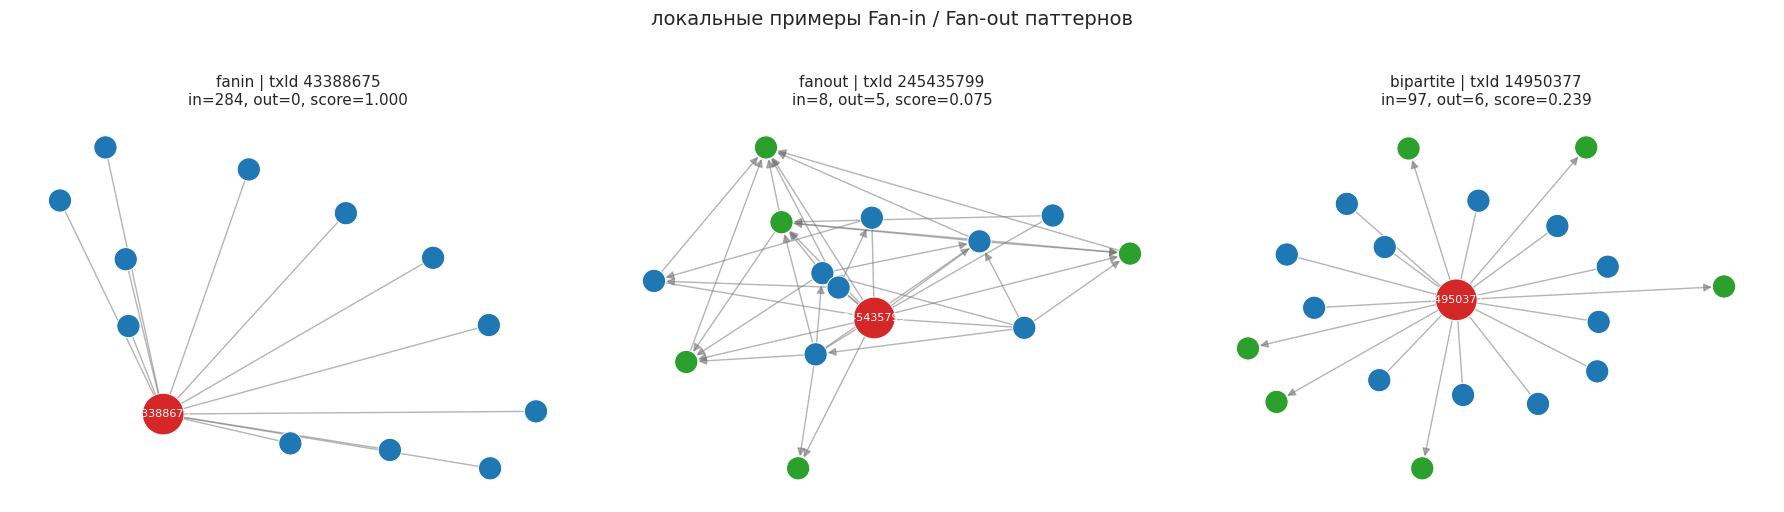

,txId,hub_type,hub_in_degree,hub_out_degree,anomalousness_score,class
0,43388675,fanin,284,0,1.0000,2
2106,245435799,fanout,8,5,0.0751,unknown
898,14950377,bipartite,97,6,0.2386,2


In [8]:
# рисуем локальный фрагмент графа вокруг выбранного hub-узла

def build_hub_ego_graph(
    graph: nx.DiGraph,
    hub_tx_id: int,
    max_in: int = 12,
    max_out: int = 12,
) -> tuple[nx.DiGraph, dict[int, str]]:
    # max_in и max_out ограничивают размер ego-графа, чтобы визуализация оставалась читаемой.
    src_nodes = list(graph.predecessors(hub_tx_id))[:max_in]
    dst_nodes = list(graph.successors(hub_tx_id))[:max_out]
    selected_nodes = [hub_tx_id] + src_nodes + dst_nodes
    subgraph = graph.subgraph(selected_nodes).copy()

    # roles задает семантику вершины на рисунке: источник, приемник, hub или смешанная роль.
    roles = {node: "source" for node in src_nodes}
    roles.update({node: "sink" for node in dst_nodes})
    for node in set(src_nodes).intersection(dst_nodes):
        roles[node] = "source_sink"
    roles[hub_tx_id] = "hub"
    return subgraph, roles


# вход: таблица найденных hub-паттернов; выход: по одному самому сильному примеру каждого типа.
def select_example_hubs(detected: pd.DataFrame) -> pd.DataFrame:
    examples = []
    for hub_type in ["fanin", "fanout", "bipartite"]:
        subset = detected[detected["hub_type"] == hub_type].copy()
        if subset.empty:
            continue
        examples.append(subset.sort_values("anomalousness_score", ascending=False).iloc[0])
    if not examples:
        return pd.DataFrame()
    return pd.DataFrame(examples)


def draw_hub_ego_graph(
    graph: nx.DiGraph,
    hub_row: pd.Series,
    ax: plt.Axes,
) -> None:
    hub_tx_id = int(hub_row["txId"])
    subgraph, roles = build_hub_ego_graph(graph, hub_tx_id)
    pos = nx.spring_layout(subgraph, seed=CONFIG["random_state"], k=0.9)

    # color_by_role делает типы соседей различимыми без подписывания всех вершин.
    color_by_role = {
        "hub": "#d62728",
        "source": "#1f77b4",
        "sink": "#2ca02c",
        "source_sink": "#9467bd",
    }
    node_colors = [color_by_role.get(roles.get(node, "sink"), "#7f7f7f") for node in subgraph.nodes]
    node_sizes = [900 if roles.get(node) == "hub" else 280 for node in subgraph.nodes]

    nx.draw_networkx_edges(
        subgraph,
        pos,
        ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=12,
        edge_color="#777777",
        alpha=0.55,
        width=1.0,
    )
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        linewidths=0.7,
        edgecolors="white",
    )
    nx.draw_networkx_labels(
        subgraph,
        pos,
        labels={hub_tx_id: str(hub_tx_id)},
        ax=ax,
        font_size=8,
        font_color="white",
    )
    ax.set_title(
        f"{hub_row['hub_type']} | txId {hub_tx_id}\n"
        f"in={int(hub_row['hub_in_degree'])}, out={int(hub_row['hub_out_degree'])}, "
        f"score={hub_row['anomalousness_score']:.3f}",
        fontsize=11,
    )
    ax.axis("off")


example_hubs_df = select_example_hubs(fanfan_detected_df)
if example_hubs_df.empty:
    print("нет hub-паттернов для визуализации")
else:
    fig, axes = plt.subplots(1, len(example_hubs_df), figsize=(6 * len(example_hubs_df), 5))
    if len(example_hubs_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, example_hubs_df.iterrows()):
        draw_hub_ego_graph(G, row, ax)

    fig.suptitle("локальные примеры Fan-in / Fan-out паттернов", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fanfan_ego_graph_examples.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    display(example_hubs_df[["txId", "hub_type", "hub_in_degree", "hub_out_degree", "anomalousness_score", "class"]])

In [9]:
# переводим найденные hub-паттерны в признаки уровня вершины

def build_hub_feature_table(nodes: pd.DataFrame, detected: pd.DataFrame) -> pd.DataFrame:
    hub_features = nodes[["txId"]].copy()
    hub_features["is_fanout_hub"] = 0
    hub_features["is_fanin_hub"] = 0
    hub_features["is_bipartite_hub"] = 0
    hub_features["anomalousness_score"] = 0.0

    if detected.empty:
        return hub_features

    detected_features = detected[
        ["txId", "hub_type", "anomalousness_score", "z_in", "z_out"]
    ].copy()
    hub_features = hub_features.merge(detected_features, on="txId", how="left")
    hub_features["hub_type"] = hub_features["hub_type"].fillna("normal")
    hub_features["anomalousness_score"] = hub_features["anomalousness_score_y"].fillna(0.0)
    hub_features = hub_features.drop(columns=["anomalousness_score_x", "anomalousness_score_y"])
    hub_features["is_fanout_hub"] = (hub_features["hub_type"] == "fanout").astype(int)
    hub_features["is_fanin_hub"] = (hub_features["hub_type"] == "fanin").astype(int)
    hub_features["is_bipartite_hub"] = (hub_features["hub_type"] == "bipartite").astype(int)
    return hub_features[
        [
            "txId",
            "is_fanout_hub",
            "is_fanin_hub",
            "is_bipartite_hub",
            "anomalousness_score",
        ]
    ]


# собираем 166 признаков elliptic, time_step и 4 fan-признака для модели

def prepare_node_features(
    nodes: pd.DataFrame,
    detected: pd.DataFrame,
) -> tuple[pd.DataFrame, list[str]]:
    model_df = nodes.copy()
    model_df["elliptic_time_step_feature"] = model_df["time_step"]
    feature_cols = ["elliptic_time_step_feature"] + [
        col for col in nodes.columns if col.startswith("feature_")
    ]
    hub_features = build_hub_feature_table(nodes, detected)
    model_df = model_df.merge(hub_features, on="txId", how="left")
    hub_cols = [
        "is_fanout_hub",
        "is_fanin_hub",
        "is_bipartite_hub",
        "anomalousness_score",
    ]
    model_df[hub_cols] = model_df[hub_cols].fillna(0)
    model_cols = feature_cols + hub_cols

    # scaler обучается только на train-времени, чтобы не подсмотреть test
    train_scale_mask = model_df["time_step"] <= CONFIG["train_timestep_max"]
    scaler = StandardScaler()
    model_df[model_cols] = model_df[model_cols].astype(float)
    scaler.fit(model_df.loc[train_scale_mask, model_cols])
    model_df[model_cols] = scaler.transform(model_df[model_cols])
    return model_df, model_cols


model_df, model_feature_cols = prepare_node_features(node_df, fanfan_detected_df)
print(f"Pipeline 2 Feature count {len(model_feature_cols)}")

Pipeline 2 Feature count 170


In [10]:
# делим размеченные вершины по времени: train/val до 34 шага, test с 35 шага

def split_train_val_indices(model_nodes: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    labeled_mask = model_nodes["label"] >= 0
    train_mask = labeled_mask & (model_nodes["time_step"] <= CONFIG["train_timestep_max"])
    test_mask = labeled_mask & (model_nodes["time_step"] >= CONFIG["test_timestep_min"])

    train_indices = model_nodes.index[train_mask].to_numpy()
    test_indices = model_nodes.index[test_mask].to_numpy()
    train_labels = model_nodes.loc[train_indices, "label"].to_numpy()

    stratify = train_labels if len(np.unique(train_labels)) == 2 else None
    train_idx, val_idx = train_test_split(
        train_indices,
        test_size=CONFIG["val_size"],
        random_state=CONFIG["random_state"],
        stratify=stratify,
    )
    return train_idx, val_idx, test_indices


# создаём boolean-mask для pytorch geometric

def make_mask(size: int, indices: np.ndarray) -> torch.Tensor:
    mask = torch.zeros(size, dtype=torch.bool)
    mask[indices] = True
    return mask


# собираем объект data: x, edge_index, y и маски train/val/test

def build_pyg_data(
    model_nodes: pd.DataFrame,
    edges: pd.DataFrame,
    feature_cols: list[str],
) -> Data:
    if not PYG_AVAILABLE:
        raise ImportError("Установи torch-geometric для запуска GAT")

    id_to_idx = {tx_id: idx for idx, tx_id in enumerate(model_nodes["txId"].tolist())}
    edge_pairs = edges.copy()
    edge_pairs["src_idx"] = edge_pairs["txId1"].map(id_to_idx)
    edge_pairs["dst_idx"] = edge_pairs["txId2"].map(id_to_idx)
    edge_pairs = edge_pairs.dropna(subset=["src_idx", "dst_idx"])

    edge_index = torch.tensor(
        edge_pairs[["src_idx", "dst_idx"]].astype(int).to_numpy().T,
        dtype=torch.long,
    )
    x = torch.tensor(model_nodes[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(model_nodes["label"].to_numpy(), dtype=torch.long)

    train_idx, val_idx, test_idx = split_train_val_indices(model_nodes)
    data = Data(x=x, edge_index=edge_index, y=y)
    data.train_mask = make_mask(len(model_nodes), train_idx)
    data.val_mask = make_mask(len(model_nodes), val_idx)
    data.test_mask = make_mask(len(model_nodes), test_idx)
    return data


if PYG_AVAILABLE:
    pyg_data = build_pyg_data(model_df, edgelist_df, model_feature_cols).to(DEVICE)
    print(f"Pipeline 2 Data nodes {pyg_data.num_nodes} edges {pyg_data.num_edges}")
    print(f"Pipeline 2 Train nodes {int(pyg_data.train_mask.sum())}")
    print(f"Pipeline 2 Val nodes {int(pyg_data.val_mask.sum())}")
    print(f"Pipeline 2 Test nodes {int(pyg_data.test_mask.sum())}")

Pipeline 2 Data nodes 203769 edges 234355
Pipeline 2 Train nodes 26904
Pipeline 2 Val nodes 2990
Pipeline 2 Test nodes 16670


In [11]:
# gat использует attention по соседям и обучается классифицировать вершины

class GATModel(torch.nn.Module):
    def __init__(self, in_channels: int) -> None:
        super().__init__()
        # первый gat-слой строит несколько attention-голов по соседям узла.
        self.conv1 = GATConv(
            in_channels,
            CONFIG["gat_hidden_channels"],
            heads=CONFIG["gat_hidden_heads"],
            dropout=CONFIG["gat_dropout"],
        )
        # второй слой сжимает multi-head embedding в общий вектор вершины.
        self.conv2 = GATConv(
            CONFIG["gat_hidden_channels"] * CONFIG["gat_hidden_heads"],
            CONFIG["gat_embedding_channels"],
            heads=1,
            concat=False,
            dropout=CONFIG["gat_dropout"],
        )
        self.linear = torch.nn.Linear(CONFIG["gat_embedding_channels"], 2)
        self.dropout = CONFIG["gat_dropout"]

    # вход: pyg Data с x и edge_index; выход: logits двух классов для каждой вершины.
    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        return self.linear(x)

    def first_layer_attention(self, data: Data):
        self.eval()
        with torch.no_grad():
            return self.conv1(
                data.x,
                data.edge_index,
                return_attention_weights=True,
            )


# считаем метрики для illicit-класса и вероятностные auc-метрики

def compute_binary_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
) -> dict[str, float]:
    if len(y_true) == 0:
        return {"precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "pr_auc": np.nan}

    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        metrics["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan
    return metrics


def evaluate_model(model: GATModel, data: Data, mask: torch.Tensor) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = logits.softmax(dim=1)[:, 1]
        preds = logits.argmax(dim=1)

    # mask выбирает нужный срез вершин: train, val, test или только hub-узлы.
    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = preds[mask].detach().cpu().numpy()
    y_prob = probs[mask].detach().cpu().numpy()
    return compute_binary_metrics(y_true, y_pred, y_prob)


# обучаем gat с class weights и early stopping по val loss

def train_gat(data: Data) -> GATModel:
    model = GATModel(data.num_node_features).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["gat_lr"],
        weight_decay=CONFIG["gat_weight_decay"],
    )
    class_weights = torch.tensor(CONFIG["class_weights"], dtype=torch.float32, device=DEVICE)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    patience_left = CONFIG["gat_patience"]

    print("Pipeline 2 Training GAT")
    for epoch in range(1, CONFIG["gat_epochs"] + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(data)
            val_loss = criterion(val_logits[data.val_mask], data.y[data.val_mask])
            val_pred = val_logits[data.val_mask].argmax(dim=1)
            val_f1 = f1_score(
                data.y[data.val_mask].detach().cpu().numpy(),
                val_pred.detach().cpu().numpy(),
                zero_division=0,
            )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_left = CONFIG["gat_patience"]
        else:
            patience_left -= 1

        if epoch % 100 == 0 or epoch == 1:
            print(
                "Pipeline 2 epoch "
                f"{epoch} loss {loss.item():.4f} val_f1 {val_f1:.4f}"
            )

        if patience_left == 0:
            print(f"Pipeline 2 early stopping epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model


if PYG_AVAILABLE:
    gat_model = train_gat(pyg_data)

Pipeline 2 Training GAT
Pipeline 2 epoch 1 loss 1.2352 val_f1 0.4316
Pipeline 2 epoch 100 loss 0.3409 val_f1 0.7855
Pipeline 2 epoch 200 loss 0.3256 val_f1 0.8098
Pipeline 2 epoch 300 loss 0.3229 val_f1 0.8173
Pipeline 2 epoch 400 loss 0.3236 val_f1 0.8296
Pipeline 2 early stopping epoch 425


In [12]:
# строим маску для оценки только на выбранных hub-вершинах

def mask_from_tx_ids(data: Data, model_nodes: pd.DataFrame, tx_ids: set[int]) -> torch.Tensor:
    mask_values = model_nodes["txId"].isin(tx_ids).to_numpy()
    return torch.tensor(mask_values, dtype=torch.bool, device=data.x.device)


def add_micro_f1(metrics: dict[str, float], y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    result = metrics.copy()
    result["micro_f1"] = f1_score(y_true, y_pred, average="micro", zero_division=0) if len(y_true) else np.nan
    return result


# оцениваем модель на произвольном срезе вершин

def evaluate_model_slice(model: GATModel, data: Data, mask: torch.Tensor) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = logits.softmax(dim=1)[:, 1]
        preds = logits.argmax(dim=1)

    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = preds[mask].detach().cpu().numpy()
    y_prob = probs[mask].detach().cpu().numpy()
    metrics = compute_binary_metrics(y_true, y_pred, y_prob)
    return add_micro_f1(metrics, y_true, y_pred)


if PYG_AVAILABLE:
    # hub_ids и bipartite_ids задают отдельные test-срезы для проверки качества именно на паттернах.
    hub_ids = set(fanfan_detected_df["txId"].astype(int).tolist())
    bipartite_ids = set(
        fanfan_detected_df.loc[
            fanfan_detected_df["hub_type"] == "bipartite",
            "txId",
        ].astype(int).tolist()
    )

    hub_test_mask = pyg_data.test_mask & mask_from_tx_ids(pyg_data, model_df, hub_ids)
    bipartite_test_mask = pyg_data.test_mask & mask_from_tx_ids(pyg_data, model_df, bipartite_ids)

    gat_all_metrics = evaluate_model_slice(gat_model, pyg_data, pyg_data.test_mask)
    gat_hub_metrics = evaluate_model_slice(gat_model, pyg_data, hub_test_mask)
    gat_bipartite_metrics = evaluate_model_slice(gat_model, pyg_data, bipartite_test_mask)

    print(
        "Pipeline 2 Test results all nodes "
        f"F1 {gat_all_metrics['f1']:.4f} AUC {gat_all_metrics['roc_auc']:.4f}"
    )
    print(
        "Pipeline 2 Test results hub nodes only "
        f"F1 {gat_hub_metrics['f1']:.4f} AUC {gat_hub_metrics['roc_auc']:.4f}"
    )
    print(
        "Pipeline 2 Test results bipartite only "
        f"F1 {gat_bipartite_metrics['f1']:.4f} AUC {gat_bipartite_metrics['roc_auc']:.4f}"
    )

Pipeline 2 Test results all nodes F1 0.4796 AUC 0.8873
Pipeline 2 Test results hub nodes only F1 0.1818 AUC 0.9110
Pipeline 2 Test results bipartite only F1 0.0000 AUC nan


In [13]:
# сохраняем предсказания gat и присоединяем hub-признаки для анализа

def save_gat_predictions(model: GATModel, data: Data, model_nodes: pd.DataFrame) -> pd.DataFrame:
    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = logits.softmax(dim=1)[:, 1].detach().cpu().numpy()
        preds = logits.argmax(dim=1).detach().cpu().numpy()

    prediction_df = model_nodes[["txId", "time_step", "label"]].copy()
    prediction_df["true_label"] = prediction_df["label"]
    prediction_df["predicted_label"] = preds
    prediction_df["illicit_prob"] = probs

    hub_info = fanfan_detected_df[
        ["txId", "hub_type", "anomalousness_score", "z_in", "z_out"]
    ].copy()
    prediction_df = prediction_df.merge(hub_info, on="txId", how="left")
    prediction_df["hub_type"] = prediction_df["hub_type"].fillna("normal")
    prediction_df[["anomalousness_score", "z_in", "z_out"]] = prediction_df[
        ["anomalousness_score", "z_in", "z_out"]
    ].fillna(0.0)

    output_path = OUTPUT_DIR / "predictions_fanfan.csv"
    prediction_df[
        [
            "txId",
            "true_label",
            "predicted_label",
            "illicit_prob",
            "hub_type",
            "anomalousness_score",
            "z_in",
            "z_out",
        ]
    ].to_csv(output_path, index=False)
    return prediction_df


if PYG_AVAILABLE:
    predictions_fanfan_df = save_gat_predictions(gat_model, pyg_data, model_df)
    print(f"Pipeline 2 Predictions saved {OUTPUT_DIR / 'predictions_fanfan.csv'}")

Pipeline 2 Predictions saved /kaggle/working/output/04_elliptic_fan_in_fan_out/predictions_fanfan.csv


In [14]:
# считаем, какую долю illicit hub-узлов метод отметил как illicit

def compute_hub_coverage(
    frame: pd.DataFrame,
    predicted_col: str,
    hub_col: str = "hub_type",
) -> float:
    illicit_hubs = frame[(frame["label"] == 1) & (frame[hub_col] != "normal")]
    if illicit_hubs.empty:
        return np.nan
    return float((illicit_hubs[predicted_col] == 1).mean())


# сравниваем классический degree-filter и flowscope-like score на test-срезе

def evaluate_classic_methods() -> pd.DataFrame:
    classic_df = hub_candidates_df[
        ["txId", "label", "time_step", "hub_type"]
    ].merge(
        fanfan_detected_df[["txId", "anomalousness_score"]],
        on="txId",
        how="left",
    )
    classic_df["anomalousness_score"] = classic_df["anomalousness_score"].fillna(0.0)
    # test_df оставляет только размеченные вершины будущих timestep, как в temporal holdout.
    test_df = classic_df[
        (classic_df["label"] >= 0)
        & (classic_df["time_step"] >= CONFIG["test_timestep_min"])
    ].copy()

    test_df["degree_pred"] = (test_df["hub_type"] != "normal").astype(int)
    test_df["flowscope_pred"] = (test_df["anomalousness_score"] >= 0.5).astype(int)
    y_true = test_df["label"].to_numpy()

    rows = []
    for method, pred_col in [
        ("Degree-filter threshold", "degree_pred"),
        ("FlowScope scoring", "flowscope_pred"),
    ]:
        y_pred = test_df[pred_col].to_numpy()
        metrics = compute_binary_metrics(y_true, y_pred, y_pred.astype(float))
        rows.append(
            {
                "Метод": method,
                "Precision": metrics["precision"],
                "Recall": metrics["recall"],
                "F1": metrics["f1"],
                "Покрытие хабов": compute_hub_coverage(test_df, pred_col),
            }
        )
    return pd.DataFrame(rows)


# собираем итоговую таблицу сравнения классики и gat

def build_comparison_table() -> pd.DataFrame:
    rows = evaluate_classic_methods().to_dict("records")
    if PYG_AVAILABLE:
        for method, metrics, mask in [
            ("GAT all nodes", gat_all_metrics, pyg_data.test_mask),
            ("GAT hub nodes only", gat_hub_metrics, hub_test_mask),
        ]:
            pred_frame = predictions_fanfan_df[
                predictions_fanfan_df["time_step"] >= CONFIG["test_timestep_min"]
            ].copy()
            rows.append(
                {
                    "Метод": method,
                    "Precision": metrics["precision"],
                    "Recall": metrics["recall"],
                    "F1": metrics["f1"],
                    "Покрытие хабов": compute_hub_coverage(
                        pred_frame,
                        "predicted_label",
                    ),
                }
            )
    return pd.DataFrame(rows)


comparison_df = build_comparison_table()
comparison_df.to_csv(OUTPUT_DIR / "fanfan_pipeline_comparison.csv", index=False)
display(comparison_df)

,Метод,Precision,Recall,F1,Покрытие хабов
0,Degree-filter threshold,0.0096,0.0083,0.0089,1.0000
1,FlowScope scoring,0.0339,0.0018,0.0035,0.2222
2,GAT all nodes,0.4451,0.5199,0.4796,0.1111
3,GAT hub nodes only,0.5000,0.1111,0.1818,0.1111


## Итоговое сравнение методов

График ниже сравнивает классические правила и GAT по основным метрикам. Для несбалансированной AML-задачи главный ориентир — `F1`, но `Precision` и `Recall` показывают, какой тип ошибки делает метод.

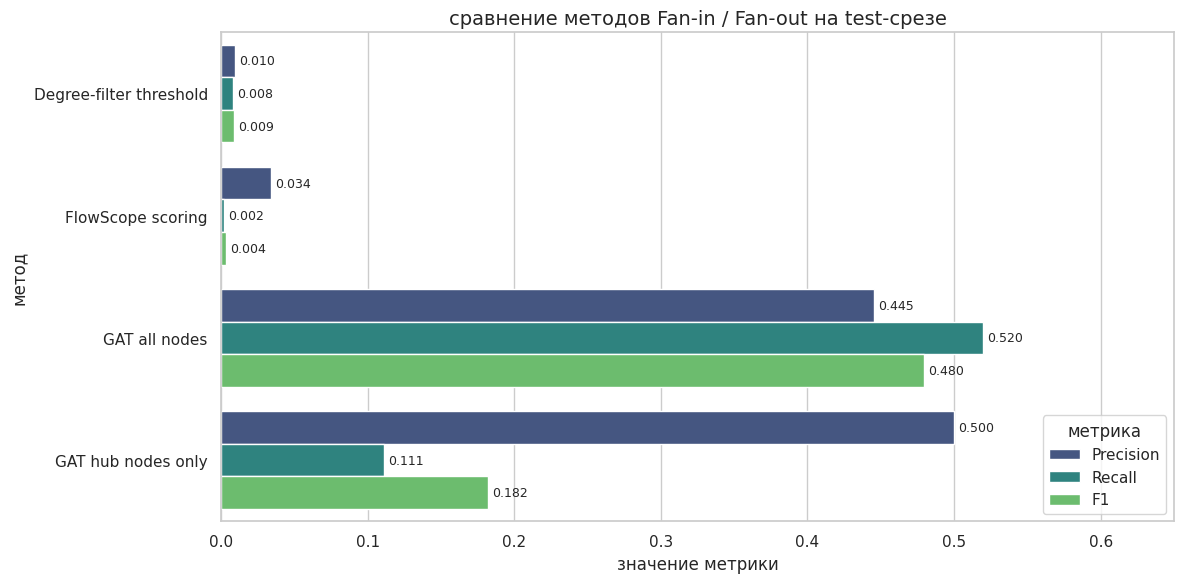

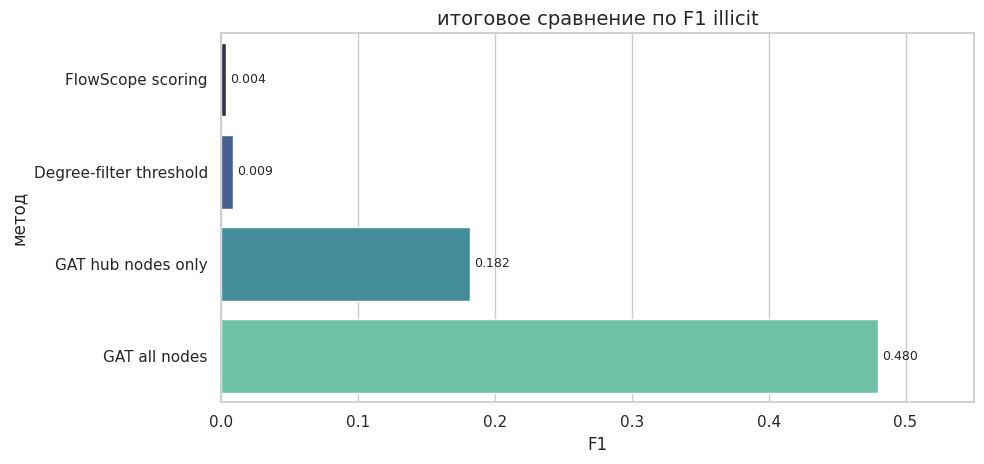

In [15]:
# строим компактное сравнение методов по precision, recall и f1

plot_comparison_df = comparison_df.copy()
method_col = plot_comparison_df.columns[0]
plot_comparison_df = plot_comparison_df.rename(columns={method_col: "method"})
metric_cols = [col for col in ["Precision", "Recall", "F1"] if col in plot_comparison_df.columns]
plot_long_df = plot_comparison_df.melt(
    id_vars="method",
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_long_df,
    x="value",
    y="method",
    hue="metric",
    palette="viridis",
    ax=ax,
)
ax.set_title("сравнение методов Fan-in / Fan-out на test-срезе", fontsize=14)
ax.set_xlabel("значение метрики")
ax.set_ylabel("метод")
ax.set_xlim(0, max(0.65, float(plot_long_df["value"].max()) + 0.08))
ax.legend(title="метрика", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fanfan_methods_comparison.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

# отдельно показываем только f1, чтобы было видно лучший итоговый метод
f1_df = plot_comparison_df[["method", "F1"]].sort_values("F1", ascending=True)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=f1_df, x="F1", y="method", palette="mako", ax=ax)
ax.set_title("итоговое сравнение по F1 illicit", fontsize=14)
ax.set_xlabel("F1")
ax.set_ylabel("метод")
ax.set_xlim(0, max(0.55, float(f1_df["F1"].max()) + 0.06))
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fanfan_f1_ranking.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

In [16]:
# сохраняем attention-соседей для нескольких bipartite hub-узлов

def save_attention_analysis(
    model: GATModel,
    data: Data,
    model_nodes: pd.DataFrame,
    sample_size: int = 10,
) -> pd.DataFrame:
    # bipartite_test_ids ограничивает анализ attention наиболее интересным типом fan-in/fan-out hub.
    bipartite_test_ids = set(
        model_nodes.loc[
            model_nodes["txId"].isin(bipartite_ids)
            & (model_nodes["time_step"] >= CONFIG["test_timestep_min"])
            & (model_nodes["label"] >= 0),
            "txId",
        ].astype(int).tolist()
    )
    if not bipartite_test_ids:
        attention_df = pd.DataFrame(columns=["hub_txId", "neighbor_txId", "attention_score", "rank"])
        attention_df.to_csv(OUTPUT_DIR / "attention_analysis.csv", index=False)
        return attention_df

    sampled_ids = random.sample(
        list(bipartite_test_ids),
        k=min(sample_size, len(bipartite_test_ids)),
    )
    tx_to_idx = {tx_id: idx for idx, tx_id in enumerate(model_nodes["txId"].tolist())}
    idx_to_tx = {idx: tx_id for tx_id, idx in tx_to_idx.items()}

    # усредняем attention по головам первого gat-слоя
    _, attention = model.first_layer_attention(data)
    edge_index, alpha = attention
    alpha_mean = alpha.mean(dim=1).detach().cpu()
    edge_index_cpu = edge_index.detach().cpu()

    records = []
    for hub_tx_id in sampled_ids:
        hub_idx = tx_to_idx[hub_tx_id]
        incoming_mask = edge_index_cpu[1] == hub_idx
        incoming_positions = incoming_mask.nonzero(as_tuple=False).flatten()
        if len(incoming_positions) == 0:
            continue
        ranked_positions = incoming_positions[
            torch.argsort(alpha_mean[incoming_positions], descending=True)
        ][:3]
        for rank, edge_pos in enumerate(ranked_positions.tolist(), start=1):
            src_idx = int(edge_index_cpu[0, edge_pos])
            records.append(
                {
                    "hub_txId": hub_tx_id,
                    "neighbor_txId": int(idx_to_tx[src_idx]),
                    "attention_score": float(alpha_mean[edge_pos]),
                    "rank": rank,
                }
            )

    attention_df = pd.DataFrame.from_records(records)
    attention_df.to_csv(OUTPUT_DIR / "attention_analysis.csv", index=False)
    return attention_df


if PYG_AVAILABLE:
    attention_analysis_df = save_attention_analysis(gat_model, pyg_data, model_df)
    print(f"Pipeline 2 Attention analysis saved {OUTPUT_DIR / 'attention_analysis.csv'}")

Pipeline 2 Attention analysis saved /kaggle/working/output/04_elliptic_fan_in_fan_out/attention_analysis.csv


## Выводы и дальнейшие шаги

В этом ноутбуке Fan-in / Fan-out оказался рабочим графовым паттерном для Elliptic. В отличие от round-trip cycles, такие структуры реально находятся в transaction graph.

Основные выводы:

- классический degree-filter хорошо находит hub-структуры, но сам по себе плохо классифицирует illicit-узлы из-за большого числа ложных срабатываний;
- FlowScope-inspired score полезен как ранжирование hub-узлов, но без сумм BTC на рёбрах остаётся proxy-метрикой;
- GAT лучше использует локальную структуру графа и hub-признаки: на hub-срезе F1 выше, чем у классических правил;
- признаки `is_fanin_hub`, `is_fanout_hub`, `is_bipartite_hub`, `anomalousness_score` стоит переносить в основную задачу классификации вершин.

Что делать дальше:

1. Добавить hub-признаки в основной ноутбук классификации узлов как отдельную группу graph features.
2. Сравнить baseline без hub-признаков и модель с hub-признаками на одинаковом temporal split.
3. Проверять качество отдельно на всех test-узлах и на hub-узлах.
4. Добавить temporal fan-in/fan-out признаки: `in_degree` и `out_degree` внутри скользящего окна по `time_step`.
5. Для текста ВКР описать Fan-in / Fan-out как практически применимый паттерн для Elliptic, а round-trip cycles как проверенную, но неподходящую гипотезу для transaction-to-transaction графа.

In [17]:
# архивируем папку output для скачивания из kaggle

import shutil

archive_base = BASE_DIR / "output_04_elliptic_fan_in_fan_out"
archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=OUTPUT_DIR,
)

print(f"архив сохранён {archive_path}")

архив сохранён /kaggle/working/output_04_elliptic_fan_in_fan_out.zip
